# Resume Screening AI
### A Machine Learning Approach to Automated Resume Classification

This notebook implements a resume classification system using Natural Language Processing and supervised machine learning. The goal is to classify resumes into job categories based on their text content.

In [17]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

## 1. Load Dataset

In this step, the resume dataset is loaded into Python.  
The dataset contains two main columns:
- `Category` → the job role label
- `Resume` → the actual resume text

In [18]:
file_path = r"C:\Users\user\OneDrive\Desktop\ai project\UpdatedResumeDataSet.csv"   

print("Current working folder:", os.getcwd())
print("Loading dataset...")

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Original columns:", df.columns.tolist())
print("Shape:", df.shape)

df.head()

Current working folder: c:\Users\user\OneDrive\Desktop\ai project
Loading dataset...
Dataset loaded successfully.
Original columns: ['Category', 'Resume']
Shape: (962, 2)


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


## 2. Keep Only the Relevant Columns

The dataset contains the label column (`Category`) and the text column (`Resume`).  
Only these two columns are needed for this project.

In [19]:
TEXT_COL = "Resume"
LABEL_COL = "Category"

if TEXT_COL not in df.columns or LABEL_COL not in df.columns:
    raise ValueError(
        f"Expected columns '{TEXT_COL}' and '{LABEL_COL}' not found.\n"
        f"Available columns: {df.columns.tolist()}"
    )

df = df[[LABEL_COL, TEXT_COL]].copy()
df = df.dropna(subset=[LABEL_COL, TEXT_COL])

df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (962, 2)


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


## 3. Clean Resume Text

Resume data is unstructured and inconsistent.  
To make it easier for the model to learn from, the text is cleaned by:
- converting everything to lowercase
- removing symbols and numbers
- removing extra spaces

This keeps the main wording intact while reducing noise.

In [30]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["cleaned"] = df[TEXT_COL].apply(clean_text)

df = df[df["cleaned"].str.len() > 0].copy()

print("Shape after text cleaning:", df.shape)
df[[LABEL_COL, "cleaned"]].head()

Shape after text cleaning: (962, 3)


,Category,cleaned
0,Data Science,skills programming languages python pandas num...
1,Data Science,education details may to may b e uit rgpv data...
2,Data Science,areas of interest deep learning control system...
3,Data Science,skills r python sap hana tableau sap hana sql ...
4,Data Science,education details mca ymcaust faridabad haryan...


## 4. Explore Category Distribution

Before training the model, it is useful to understand how many resumes exist in each category.  
This helps identify whether some classes are more common than others.

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64


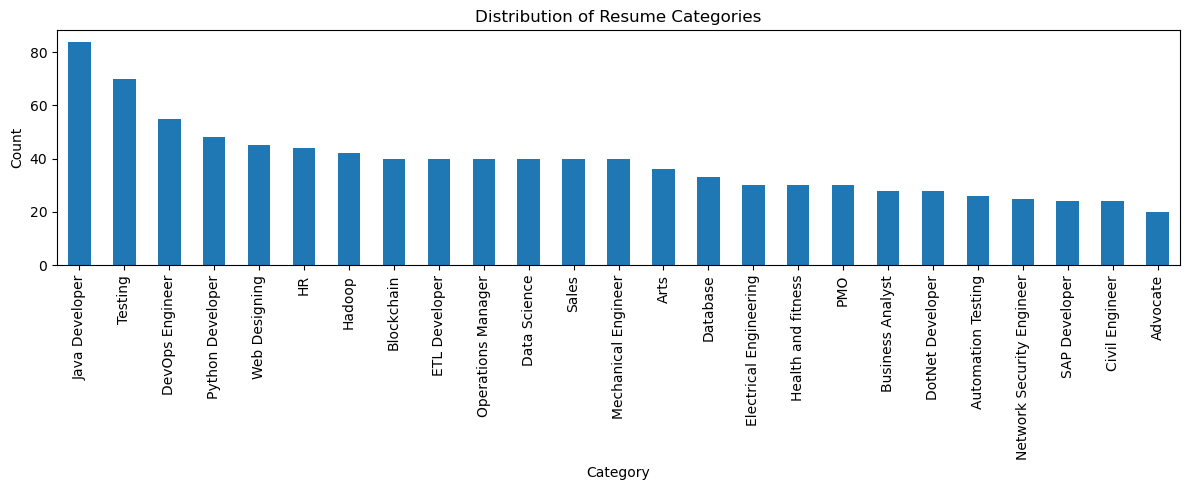

In [31]:
print(df[LABEL_COL].value_counts())

plt.figure(figsize=(12, 5))
df[LABEL_COL].value_counts().plot(kind="bar")
plt.title("Distribution of Resume Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. Split the Dataset

The data is split into:
- 80% training data
- 20% testing data

The training set is used to teach the model.  
The testing set is used to evaluate how well the model performs on unseen resumes.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned"],
    df[LABEL_COL],
    test_size=0.2,
    random_state=42,
    stratify=df[LABEL_COL]
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 769
Test size: 193


## 6. Convert Text into Numerical Features Using TF-IDF

Machine learning models cannot directly understand raw text.  
So the resumes must be converted into numbers.

This project uses **TF-IDF (Term Frequency–Inverse Document Frequency)**.

TF-IDF works by giving each word a score based on:
- how often it appears in one resume
- how rare it is across the whole dataset

This helps reduce the impact of very common words and gives more importance to words that are more specific to certain job categories.

For example:
- common words like "the" or "experience" get low weight
- role-specific words like "python", "recruitment", or "testing" get higher weight

In [33]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_vec.shape)
print("TF-IDF test shape:", X_test_vec.shape)

TF-IDF train shape: (769, 5000)
TF-IDF test shape: (193, 5000)


## 7. Train Machine Learning Models

Three models are used in this project:

1. **Logistic Regression**  
   A strong baseline model for text classification. It performs well with high-dimensional TF-IDF features.

2. **Multinomial Naive Bayes**  
   A probabilistic model that works especially well when classification depends strongly on keyword patterns.

3. **Random Forest**  
   An ensemble model based on multiple decision trees. It is more complex than the other two models and is included for comparison.

In [34]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
}

trained_models = {}
results = []

## 8. Train and Evaluate Models

Each model is trained on the training set and tested on the testing set.

The models are evaluated using:
- **Accuracy** → overall correctness
- **Precision** → how reliable the predictions are
- **Recall** → how many actual cases were correctly identified
- **F1-score** → balance between precision and recall

In [35]:
for name, model in models.items():
    print(f"\n==============================")
    print(f"Training: {name}")
    print(f"==============================")

    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    trained_models[name] = model

    acc = accuracy_score(y_test, preds)
    results.append({"Model": name, "Accuracy": acc})

    print("Accuracy:", round(acc, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, preds))


Training: Logistic Regression
Accuracy: 0.9948

Classification Report:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00

## 9. Compare Model Accuracy

This chart compares the overall accuracy of the three models.

                 Model  Accuracy
2        Random Forest  1.000000
0  Logistic Regression  0.994819
1          Naive Bayes  0.953368


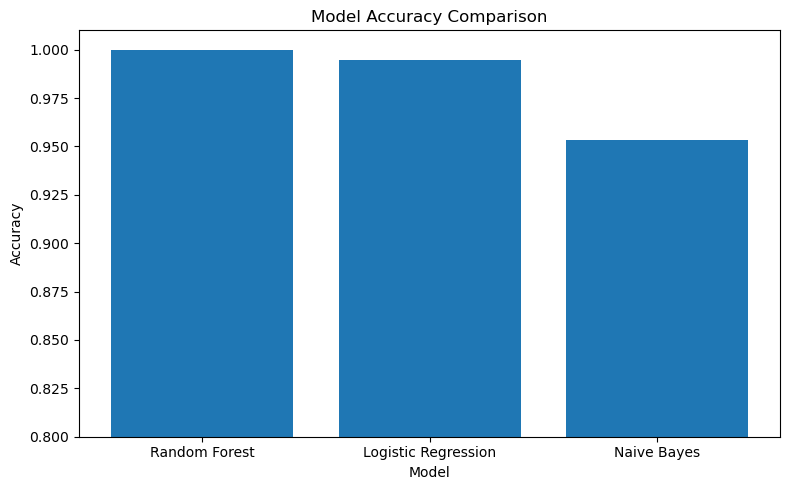

In [36]:
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print(results_df)

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.01)
plt.tight_layout()
plt.show()

## 10. Confusion Matrix for the Best Model

A confusion matrix helps visualize how well the best model classified each category.

Values along the diagonal represent correct predictions.  
Off-diagonal values represent misclassifications.

Best model: Random Forest


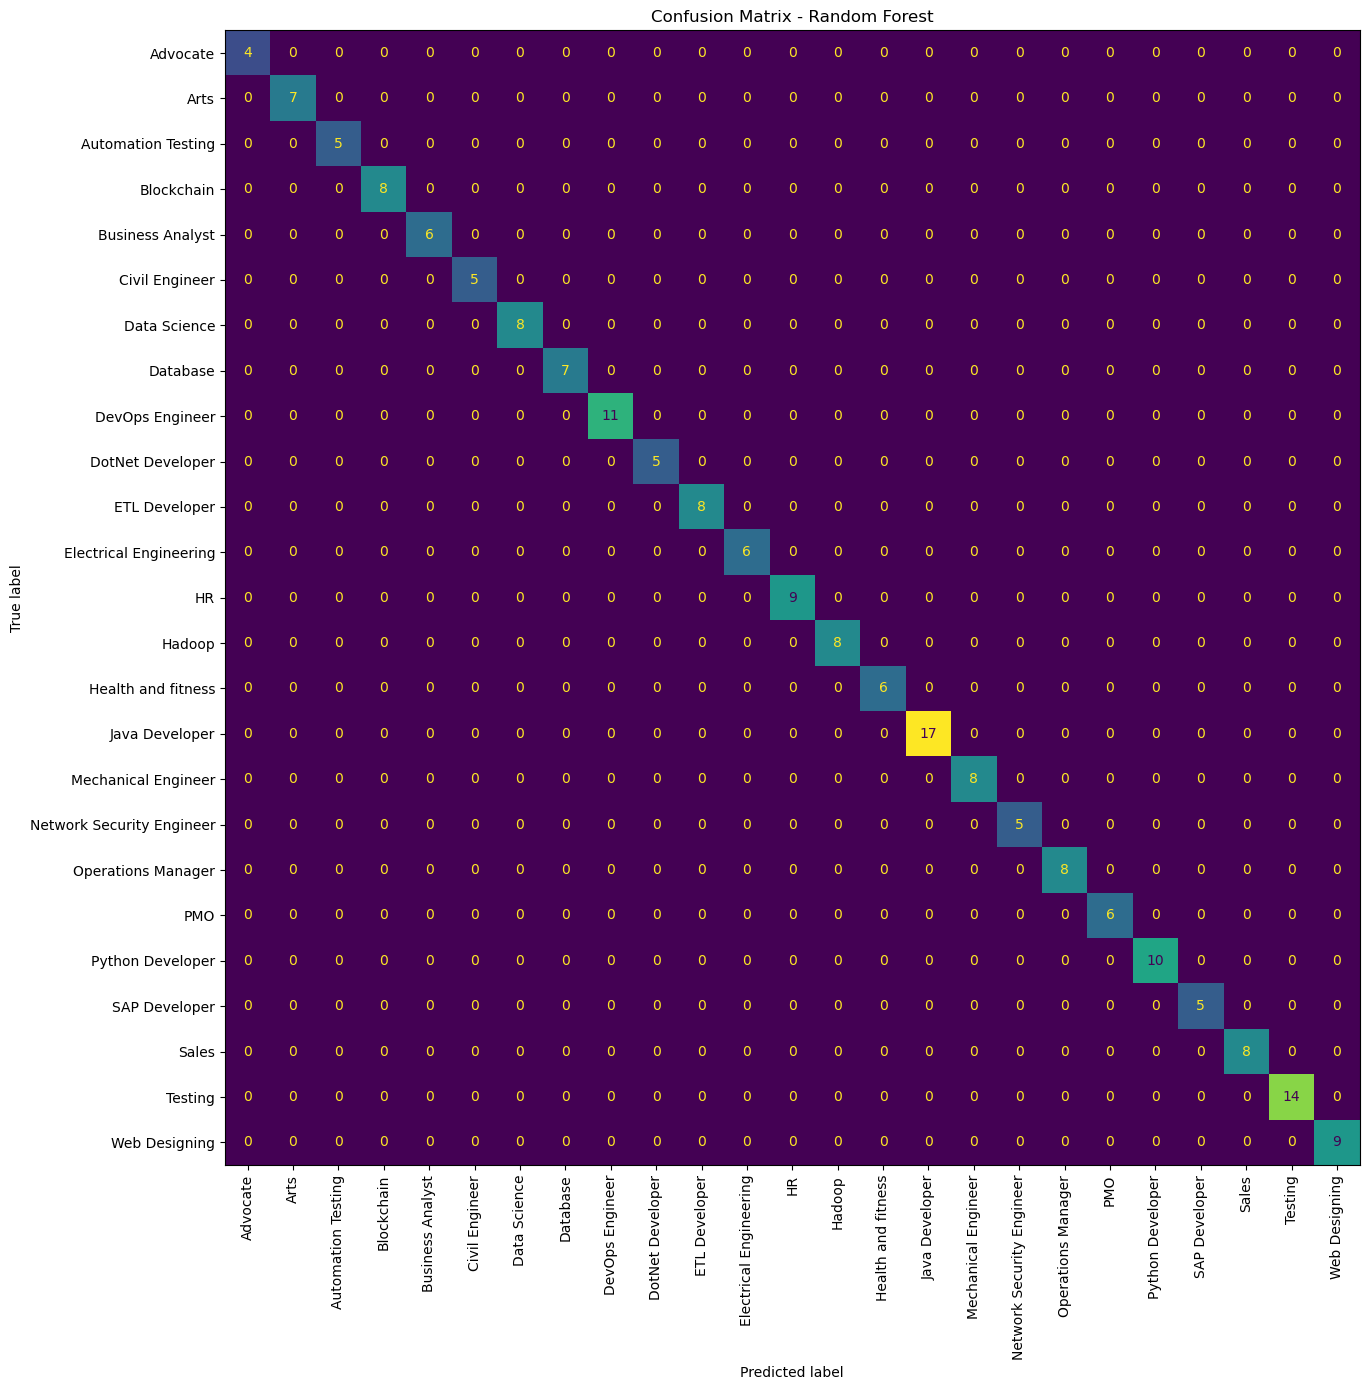

In [37]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_preds = best_model.predict(X_test_vec)

print("Best model:", best_model_name)

cm = confusion_matrix(y_test, best_preds, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(14, 14))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## 11. Test the Model with Sample Resumes

To simulate real-world use, sample resumes are entered manually and passed through the trained model.

In [38]:
sample_resumes = [
    """
    Experienced Python developer with strong machine learning, data analysis,
    pandas, numpy, scikit-learn, SQL, and data visualization skills.
    """,
    """
    Experienced HR professional with recruitment, onboarding, employee relations,
    talent acquisition, performance management, and HR policy administration.
    """,
    """
    Skilled QA engineer with manual testing, Selenium automation, bug tracking,
    test case design, and regression testing experience.
    """
]

print("Sample Predictions:")
for i, sample in enumerate(sample_resumes, start=1):
    sample_clean = clean_text(sample)
    sample_vec = tfidf.transform([sample_clean])
    sample_pred = best_model.predict(sample_vec)[0]

    print(f"\nSample Resume {i}:")
    print(sample.strip())
    print("Predicted Category:", sample_pred)

Sample Predictions:

Sample Resume 1:
Experienced Python developer with strong machine learning, data analysis,
    pandas, numpy, scikit-learn, SQL, and data visualization skills.
Predicted Category: Data Science

Sample Resume 2:
Experienced HR professional with recruitment, onboarding, employee relations,
    talent acquisition, performance management, and HR policy administration.
Predicted Category: HR

Sample Resume 3:
Skilled QA engineer with manual testing, Selenium automation, bug tracking,
    test case design, and regression testing experience.
Predicted Category: Automation Testing


## 12. Optional: Inspect Important Words

For Logistic Regression, it is possible to inspect which words are most strongly associated with certain categories.

This gives some insight into what the model is learning.

In [39]:
if "Logistic Regression" in trained_models:
    lr_model = trained_models["Logistic Regression"]
    feature_names = np.array(tfidf.get_feature_names_out())

    print("Top indicative words for a few classes:")
    classes_to_show = min(5, len(lr_model.classes_))

    for class_index in range(classes_to_show):
        top10 = np.argsort(lr_model.coef_[class_index])[-10:]
        print(f"\nClass: {lr_model.classes_[class_index]}")
        print(", ".join(feature_names[top10]))

Top indicative words for a few classes:

Class: Advocate
chennai, gst, tax, criminal, courts, court, llb, legal, law, advocate

Class: Arts
craft, ymca, ghatkopar, workshop, championship, total, days, painting, karate, arts

Class: Automation Testing
excellent, good, qtp, box, manual, selenium, tester, test, testing, automation

Class: Blockchain
parson, nashik, corpcloud, contracts, virtual, iit, technology, smart, ethereum, blockchain

Class: Business Analyst
mumbai, excel, maintain, functional, test, requirement, report, cash, business, analyst


## 13. Final Observation

The results show that resume classification can be performed effectively using machine learning and TF-IDF features.

Even relatively simple models performed strongly, which suggests that feature representation played a major role in the success of this project.

One important note is that extremely high accuracy, especially from Random Forest, should be interpreted carefully, since it may indicate that the dataset is easy to separate or that the model is fitting the data very strongly.